# 🌐 Enterprise Knowledge Graph Construction with Neo4j Aura Cloud & Groq LLM

**Masterclass: Graph Database Modeling, Automated Entity-Relationship Extraction & Graph Analytics**

Knowledge Graphs transform unstructured textual information into structured, queryable networks of entities and relationships. While traditional vector databases excel at finding semantically similar paragraphs, they struggle with multi-hop reasoning, complex relational queries, and causal dependency chains.

By coupling high-speed LLMs (**Groq `openai/gpt-oss-120b`**) with an enterprise cloud graph database (**Neo4j Aura Cloud**), we can automatically extract semantic ontologies, ingest property graphs, analyze network topology, and perform multi-hop traversals.

---

![Neo4j Knowledge Graph Architecture](workflow_neo4j_knowledge_graph.png)

<details>
<summary><b>🔍 Click to Expand Interactive Mermaid Architecture Diagram</b></summary>

```mermaid
flowchart TD
    subgraph Ingest["Source Documents & Unstructured Text"]
        DOCS["Raw Enterprise Documents<br/>(AI & Semiconductor Ecosystem)"]
        CHUNKER["Recursive Character Text Splitter<br/>(Semantically Bound Passages)"]
    end

    subgraph Extraction["LLM Entity-Relationship Extraction Plane"]
        PROMPT["Zero-Shot Extraction Prompt<br/>(Entity Types & Relation Ontologies)"]
        GROQ_LLM["Groq High-Speed LLM<br/><b>openai/gpt-oss-120b</b>"]
        PYDANTIC["Structured Schema Parser<br/>(Entity: Name, Label, Desc<br/>Relationship: Source, Target, Type)"]
    end

    subgraph Validation["Disambiguation & Graph Modeling"]
        DEDUP["Entity Normalization & Deduplication<br/>(Alias Resolution, ID Canonicalization)"]
        CYPHER_BUILD["Parameterized Cypher Generator<br/>(MERGE Nodes & Relationships)"]
    end

    subgraph Storage["Graph Database Layer"]
        NEO4J[("Neo4j Aura Cloud Database<br/><b>High-Availability Property Graph</b>")]
        TOPOLOGY["Graph Topology & Centrality Engine<br/>(PageRank, Degree & Betweenness)"]
    end

    subgraph Visual["Visual Discovery & Analytics"]
        NETWORKX["NetworkX Graph Traversal<br/>(K-Hop Neighborhoods & Shortest Paths)"]
        PLOT["Interactive Network Topology Plot<br/>(Color-Coded Communities)"]
    end

    DOCS --> CHUNKER
    CHUNKER --> PROMPT
    PROMPT --> GROQ_LLM
    GROQ_LLM --> PYDANTIC
    PYDANTIC --> DEDUP
    DEDUP --> CYPHER_BUILD
    CYPHER_BUILD --> NEO4J
    NEO4J --> TOPOLOGY
    NEO4J --> NETWORKX
    NETWORKX --> PLOT
```
</details>

---


In [1]:
"""
Here we set up our workspace by loading secret environment keys from our .env file.
We import all the tools we will need today, including the official Neo4j cloud driver,
our Groq language model client, Pydantic for defining clean data blueprints,
and NetworkX for analyzing the shape and connections of our graph.
"""
import os
import sys
import json
import time
from typing import List, Optional
from dotenv import load_dotenv

# Load credentials from .env
load_dotenv()

# Verify required keys
assert os.getenv("GROQ_API_KEY"), "Missing GROQ_API_KEY in .env"
assert os.getenv("NEO4J_URI"), "Missing NEO4J_URI in .env"
assert os.getenv("NEO4J_PASSWORD"), "Missing NEO4J_PASSWORD in .env"

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from pydantic import BaseModel, Field
from neo4j import GraphDatabase
from langchain_groq import ChatGroq

print("✅ All libraries imported and environment variables successfully verified!")


✅ All libraries imported and environment variables successfully verified!


In [2]:
"""
Now we connect directly to our live Neo4j Aura Cloud database.
We read the cloud URI and credentials from our environment, and test the connection
by asking the server to confirm it is awake and ready to accept graph commands.
"""
neo4j_uri = os.getenv("NEO4J_URI")
neo4j_user = os.getenv("NEO4J_USERNAME", "neo4j")
neo4j_pwd = os.getenv("NEO4J_PASSWORD")
neo4j_db = os.getenv("NEO4J_DATABASE", "neo4j")

# Establish high-performance cloud driver connection
driver = GraphDatabase.driver(
    neo4j_uri,
    auth=(neo4j_user, neo4j_pwd)
)

# Verify connectivity
driver.verify_connectivity()
print(f"✅ Successfully established live connection to Neo4j Aura Cloud at: {neo4j_uri}")


✅ Successfully established live connection to Neo4j Aura Cloud at: neo4j+ssc://82bce487.databases.neo4j.io


In [3]:
"""
To make sure our notebook runs cleanly from scratch without duplicate or leftover data,
we clear out any previous nodes and relationships in our database.
This gives us a fresh, spotless canvas before we build our new knowledge graph.
"""
with driver.session(database=neo4j_db) as session:
    # Remove existing graph records
    session.run("MATCH (n) DETACH DELETE n")
    
    # Verify the database is empty
    count_result = session.run("MATCH (n) RETURN count(n) AS node_count").single()
    print(f"🧹 Database reset complete! Current active nodes: {count_result['node_count']}")


🧹 Database reset complete! Current active nodes: 0


In [4]:
"""
Here we define the blueprints for our knowledge graph using Pydantic.
Every item in our world will be an Entity (like a Company, Person, or Technology),
and every link between two items will be a Relationship (like FOUNDED_BY or SUPPLIES_TO).
Having these clear rules ensures the AI extracts clean, structured data every time.
"""
class Entity(BaseModel):
    name: str = Field(description="The unique canonical name of the entity, e.g. 'NVIDIA' or 'Sam Altman'")
    type: str = Field(description="The category of the entity, such as 'Company', 'Person', 'Hardware', 'Model', or 'Technology'")
    description: str = Field(description="A brief 1-sentence summary of what this entity is or does")

class Relationship(BaseModel):
    source: str = Field(description="The exact name of the starting entity")
    target: str = Field(description="The exact name of the destination entity")
    type: str = Field(description="The uppercase relationship verb, e.g. 'FOUNDED_BY', 'SUPPLIES_TO', 'DEVELOPED', 'PARTNERED_WITH'")
    description: str = Field(description="A brief explanation of how these two entities are connected")

class KnowledgeGraph(BaseModel):
    entities: List[Entity] = Field(description="List of all unique real-world entities identified in the text")
    relationships: List[Relationship] = Field(description="List of all directed factual connections between the entities")

print("📋 Knowledge Graph Pydantic schemas created successfully!")


📋 Knowledge Graph Pydantic schemas created successfully!


In [5]:
"""
We initialize our Groq language model using the high-capability 'openai/gpt-oss-120b' engine.
By binding our KnowledgeGraph schema with structured outputs, we instruct the model
to always reply in perfectly formatted, strictly typed JSON rather than casual conversation.
"""
llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0.0
)

structured_extractor = llm.with_structured_output(KnowledgeGraph)
print("🤖 Groq structured entity-relationship extractor ready to process documents!")


🤖 Groq structured entity-relationship extractor ready to process documents!


In [6]:
"""
Here we provide a comprehensive real-world dataset describing the modern Artificial Intelligence
and semiconductor ecosystem. It describes the deep relationships between chip designers,
silicon foundries, lithography tool makers, cloud platforms, and frontier AI research labs.
"""
corpus_documents = [
    (
        "Doc 1: The Silicon Foundation (ASML, TSMC, NVIDIA)",
        "ASML is a Dutch multinational corporation that is the sole manufacturer of Extreme Ultraviolet (EUV) "
        "photolithography machines in the world. ASML supplies these critical EUV machines exclusively to top semiconductor "
        "foundries, primarily TSMC (Taiwan Semiconductor Manufacturing Company). TSMC manufactures advanced microchips "
        "and graphics processing units for NVIDIA. NVIDIA, founded and led by CEO Jensen Huang, designs state-of-the-art "
        "accelerators including the H100, H200, and Blackwell B200 GPUs. NVIDIA's GPUs rely on High-Bandwidth Memory (HBM3e) "
        "supplied by SK Hynix and Micron to train modern frontier AI foundation models."
    ),
    (
        "Doc 2: The Frontier AI Lab Ecosystem (OpenAI, Microsoft, Anthropic)",
        "OpenAI is a leading artificial intelligence research organization co-founded by Sam Altman, Greg Brockman, and Ilya Sutskever. "
        "OpenAI developed the GPT-4 and ChatGPT large language models. Microsoft, led by CEO Satya Nadella, invested billions "
        "of dollars into OpenAI and secured an exclusive cloud partnership. Microsoft Azure hosts the supercomputing clusters "
        "powered by tens of thousands of NVIDIA GPUs that train and serve OpenAI's models. OpenAI uses Microsoft Azure as its primary "
        "cloud computing backbone."
    ),
    (
        "Doc 3: Competitors and the Transformer Legacy (Google DeepMind, Anthropic, Meta)",
        "In 2017, researchers at Google Brain published the landmark paper 'Attention Is All You Need', introducing the Transformer "
        "architecture that underpins all modern generative AI. Google DeepMind, directed by Demis Hassabis, developed the Gemini 1.5 "
        "multimodal model family, training them on Google's proprietary Tensor Processing Units (TPUs). Anthropic, an AI safety lab "
        "founded by former OpenAI VP Dario Amodei and Daniela Amodei, developed the Claude 3.5 Sonnet model. Anthropic maintains "
        "a primary cloud and compute partnership with Amazon AWS. Meanwhile, Meta AI, led by Mark Zuckerberg and chief scientist "
        "Yann LeCun, released the open-source LLaMA 3 model family, which was trained on clusters of over 24,000 NVIDIA H100 GPUs."
    )
]

print(f"📚 Loaded {len(corpus_documents)} rich domain documents covering the AI & Semiconductor supply chain!")


📚 Loaded 3 rich domain documents covering the AI & Semiconductor supply chain!


In [7]:
"""
Now we send each document passage to our Groq language model.
The model reads the text and automatically extracts all key entities (companies, people, hardware)
and every directed relationship connecting them, converting unstructured paragraphs into structured facts.
"""
all_entities = {}
all_relationships = []

extraction_prompt_template = """
You are an expert Knowledge Graph architect and ontology engineer.
Extract all meaningful entities and their directional relationships from the following text.
Be thorough and extract all companies, individuals, hardware systems, models, and architectures.

Passage Title: {title}
Passage Content:
{content}
"""

print("⏳ Extracting entities and relationships using Groq...")
for title, text in corpus_documents:
    prompt = extraction_prompt_template.format(title=title, content=text)
    result = structured_extractor.invoke(prompt)
    
    # Store unique entities
    for ent in result.entities:
        all_entities[ent.name] = ent
        
    # Store relationships
    for rel in result.relationships:
        all_relationships.append(rel)
    print(f"  • Processed: {title} -> Found {len(result.entities)} entities, {len(result.relationships)} relationships.")

print(f"\n🎯 Total Unique Entities Extracted: {len(all_entities)}")
print(f"🎯 Total Relationships Extracted: {len(all_relationships)}")


⏳ Extracting entities and relationships using Groq...
  • Processed: Doc 1: The Silicon Foundation (ASML, TSMC, NVIDIA) -> Found 15 entities, 15 relationships.
  • Processed: Doc 2: The Frontier AI Lab Ecosystem (OpenAI, Microsoft, Anthropic) -> Found 12 entities, 13 relationships.
  • Processed: Doc 3: Competitors and the Transformer Legacy (Google DeepMind, Anthropic, Meta) -> Found 19 entities, 16 relationships.

🎯 Total Unique Entities Extracted: 43
🎯 Total Relationships Extracted: 44


In [8]:
"""
Let us inspect the extracted entities and relationships in friendly tabular scorecards.
This lets us visually verify that names, categories, and directional relationships
match our expectations before we write them into our Neo4j database.
"""
# Create Entities DataFrame
df_entities = pd.DataFrame([
    {"Name": e.name, "Type": e.type, "Description": e.description}
    for e in all_entities.values()
])

# Create Relationships DataFrame
df_relations = pd.DataFrame([
    {"Source": r.source, "Relationship": r.type, "Target": r.target, "Description": r.description}
    for r in all_relationships
])

print("=== 📌 SAMPLE EXTRACTED ENTITIES ===")
display(df_entities.head(10))

print("\n=== 🔗 SAMPLE EXTRACTED RELATIONSHIPS ===")
display(df_relations.head(12))


=== 📌 SAMPLE EXTRACTED ENTITIES ===


,Name,Type,Description
0,ASML,Company,Dutch multinational corporation that manufactu...
1,Extreme Ultraviolet (EUV) photolithography mac...,Hardware,Photolithography machines used for semiconduct...
2,TSMC,Company,"Taiwan Semiconductor Manufacturing Company, a ..."
3,NVIDIA,Company,GPU manufacturer
4,Jensen Huang,Person,Founder and CEO of NVIDIA
5,H100 GPU,Model,State‑of‑the‑art GPU accelerator from NVIDIA
6,H200 GPU,Model,State‑of‑the‑art GPU accelerator from NVIDIA
7,Blackwell B200 GPU,Model,State‑of‑the‑art GPU accelerator from NVIDIA
8,High‑Bandwidth Memory (HBM3e),Technology,High‑bandwidth memory used in modern AI GPUs
9,SK Hynix,Company,Semiconductor memory manufacturer



=== 🔗 SAMPLE EXTRACTED RELATIONSHIPS ===


,Source,Relationship,Target,Description
0,ASML,MANUFACTURES,Extreme Ultraviolet (EUV) photolithography mac...,ASML is the sole manufacturer of EUV photolith...
1,ASML,SUPPLIES_TO,TSMC,ASML supplies EUV machines exclusively to TSMC
2,TSMC,MANUFACTURES,Advanced microchips,TSMC manufactures advanced microchips
3,TSMC,MANUFACTURES,Graphics processing units,TSMC manufactures GPUs for NVIDIA
4,Advanced microchips,SUPPLIED_TO,NVIDIA,Advanced microchips are supplied to NVIDIA
5,Graphics processing units,SUPPLIED_TO,NVIDIA,GPUs are supplied to NVIDIA
6,NVIDIA,DESIGNS,H100 GPU,NVIDIA designs the H100 GPU
7,NVIDIA,DESIGNS,H200 GPU,NVIDIA designs the H200 GPU
8,NVIDIA,DESIGNS,Blackwell B200 GPU,NVIDIA designs the Blackwell B200 GPU
9,Jensen Huang,FOUNDED,NVIDIA,Jensen Huang founded NVIDIA


In [9]:
"""
Now comes the exciting step: writing our knowledge graph into Neo4j Aura Cloud!
We use parameterized Cypher queries with the 'MERGE' command.
Using MERGE is best practice because it automatically avoids creating duplicate nodes or edges
if an entity appears multiple times across different documents.
"""
with driver.session(database=neo4j_db) as session:
    # 1. Ingest all Entities as Nodes with dynamic labels
    for ent in all_entities.values():
        safe_type = ent.type.replace(" ", "_").replace("-", "_")
        query_node = f"""
        MERGE (n:{safe_type} {{name: $name}})
        SET n.description = $description,
            n.category = $category
        """
        session.run(query_node, name=ent.name, description=ent.description, category=ent.type)
        
    print(f"✅ Ingested {len(all_entities)} unique nodes into Neo4j!")

    # 2. Ingest all Relationships as Directed Edges
    for rel in all_relationships:
        safe_rel_type = rel.type.replace(" ", "_").replace("-", "_").upper()
        query_rel = f"""
        MATCH (s {{name: $source}})
        MATCH (t {{name: $target}})
        MERGE (s)-[r:{safe_rel_type}]->(t)
        SET r.description = $description
        """
        session.run(query_rel, source=rel.source, target=rel.target, description=rel.description)
        
    print(f"✅ Ingested {len(all_relationships)} directed edges into Neo4j!")


✅ Ingested 43 unique nodes into Neo4j!
✅ Ingested 44 directed edges into Neo4j!


In [10]:
"""
Let us run a few Cypher queries directly against our live Neo4j database to check its vital statistics.
We count how many nodes exist for each category and see which relationship types are most common.
"""
with driver.session(database=neo4j_db) as session:
    # Node count by label
    node_stats = session.run("""
    MATCH (n)
    RETURN labels(n)[0] AS Label, count(n) AS Count
    ORDER BY Count DESC
    """).data()
    
    # Relationship counts by type
    rel_stats = session.run("""
    MATCH ()-[r]->()
    RETURN type(r) AS RelationshipType, count(r) AS Frequency
    ORDER BY Frequency DESC
    """).data()

print("=== 📊 NEO4J NODE DISTRIBUTION ===")
display(pd.DataFrame(node_stats))

print("\n=== 📊 NEO4J RELATIONSHIP TYPE DISTRIBUTION ===")
display(pd.DataFrame(rel_stats).head(10))


=== 📊 NEO4J NODE DISTRIBUTION ===


,Label,Count
0,Company,12
1,Person,10
2,Model,8
3,Hardware,5
4,Technology,2
5,Product,2
6,Concept,1
7,Country,1
8,Platform,1
9,Paper,1



=== 📊 NEO4J RELATIONSHIP TYPE DISTRIBUTION ===


,RelationshipType,Frequency
0,FOUNDED_BY,5
1,DEVELOPED,4
2,MANUFACTURES,3
3,DESIGNS,3
4,SUPPLIES,2
5,SUPPLIED_TO,2
6,TRAINED_BY,2
7,TRAINED_ON,2
8,SUPPLIES_TO,1
9,BASED_IN,1


In [11]:
"""
Here we perform deep topological analysis using NetworkX.
We calculate two essential network science metrics:
1. Degree Centrality: Measures how many direct connections a node has (popularity).
2. Betweenness Centrality: Measures how often a node sits on the shortest path between other entities.
Nodes with high betweenness act as critical bridges and single-point-of-failure bottlenecks in the supply chain!
"""
# Build NetworkX graph from Neo4j records
G = nx.DiGraph()

with driver.session(database=neo4j_db) as session:
    records = session.run("""
    MATCH (s)-[r]->(t)
    RETURN s.name AS source, type(r) AS rel, t.name AS target
    """).data()
    
    for rec in records:
        G.add_edge(rec["source"], rec["target"], relationship=rec["rel"])

degree_cent = nx.degree_centrality(G)
between_cent = nx.betweenness_centrality(G)

metrics = []
for node in G.nodes():
    metrics.append({
        "Entity": node,
        "Connections (Degree)": G.degree(node),
        "Degree Centrality": round(degree_cent[node], 4),
        "Betweenness Centrality": round(between_cent[node], 4)
    })

df_metrics = pd.DataFrame(metrics).sort_values(by="Betweenness Centrality", ascending=False)

print("=== 🏆 TOP BOTTLENECK & CONNECTOR ENTITIES IN KNOWLEDGE GRAPH ===")
display(df_metrics.head(10))


=== 🏆 TOP BOTTLENECK & CONNECTOR ENTITIES IN KNOWLEDGE GRAPH ===


,Entity,Connections (Degree),Degree Centrality,Betweenness Centrality
6,NVIDIA,8,0.1951,0.0195
14,OpenAI,8,0.1951,0.0195
17,Microsoft Azure,2,0.0488,0.0061
41,NVIDIA H100 GPU,2,0.0488,0.0061
21,Microsoft,2,0.0488,0.0055
34,Dario Amodei,2,0.0488,0.0055
23,Supercomputing Clusters,2,0.0488,0.0049
2,TSMC,3,0.0732,0.0043
40,LLaMA 3,2,0.0488,0.0037
5,Graphics processing units,2,0.0488,0.0030


In [12]:
"""
Now we test multi-hop path discovery using Cypher queries.
We ask Neo4j to find the shortest supply chain path connecting ASML (the Dutch lithography machine maker)
all the way to OpenAI or ChatGPT.
This is something standard vector search cannot do, because it requires hopping through multiple steps!
"""
with driver.session(database=neo4j_db) as session:
    path_result = session.run("""
    MATCH p = shortestPath((start:Entity {name: 'ASML'})-[*..6]-(end:Entity {name: 'OpenAI'}))
    RETURN [node in nodes(p) | node.name] AS PathNodes,
           [rel in relationships(p) | type(rel)] AS Relationships
    """).data()
    
    if not path_result:
        # Fallback to broader match without label restriction
        path_result = session.run("""
        MATCH p = shortestPath((start {name: 'ASML'})-[*..6]-(end {name: 'OpenAI'}))
        RETURN [node in nodes(p) | node.name] AS PathNodes,
               [rel in relationships(p) | type(rel)] AS Relationships
        """).data()

print("=== 🛣️ MULTI-HOP PATH DISCOVERY: ASML ➔ OPENAI ===")
if path_result:
    nodes = path_result[0]["PathNodes"]
    rels = path_result[0]["Relationships"]
    chain_str = ""
    for i in range(len(rels)):
        chain_str += f"{nodes[i]} ──[{rels[i]}]──▶ "
    chain_str += nodes[-1]
    print(chain_str)
else:
    print("No direct path found under 6 hops.")


Received notification from DBMS server: <GqlStatusObject gql_status='01N50', status_description='warn: label does not exist. The label `Entity` does not exist in database `82bce487`. Verify that the spelling is correct.', position=<SummaryInputPosition line=2, column=35, offset=35>, raw_classification='UNRECOGNIZED', classification=<NotificationClassification.UNRECOGNIZED: 'UNRECOGNIZED'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'UNRECOGNIZED', '_severity': 'WARNING', '_position': {'offset': 35, 'line': 2, 'column': 35}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: "\n    MATCH p = shortestPath((start:Entity {name: 'ASML'})-[*..6]-(end:Entity {name: 'OpenAI'}))\n    RETURN [node in nodes(p) | node.name] AS PathNodes,\n           [rel in relationships(p) | type(rel)] AS Relationships\n    "
Received notification from DBMS server: <GqlStatusObject gql_status='01N50', status_description

=== 🛣️ MULTI-HOP PATH DISCOVERY: ASML ➔ OPENAI ===
No direct path found under 6 hops.


C:\Users\itsar\AppData\Local\Temp\ipykernel_13504\3284141984.py:51: UserWarning: Glyph 127760 (\N{GLOBE WITH MERIDIANS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\RAG\Code\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 127760 (\N{GLOBE WITH MERIDIANS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


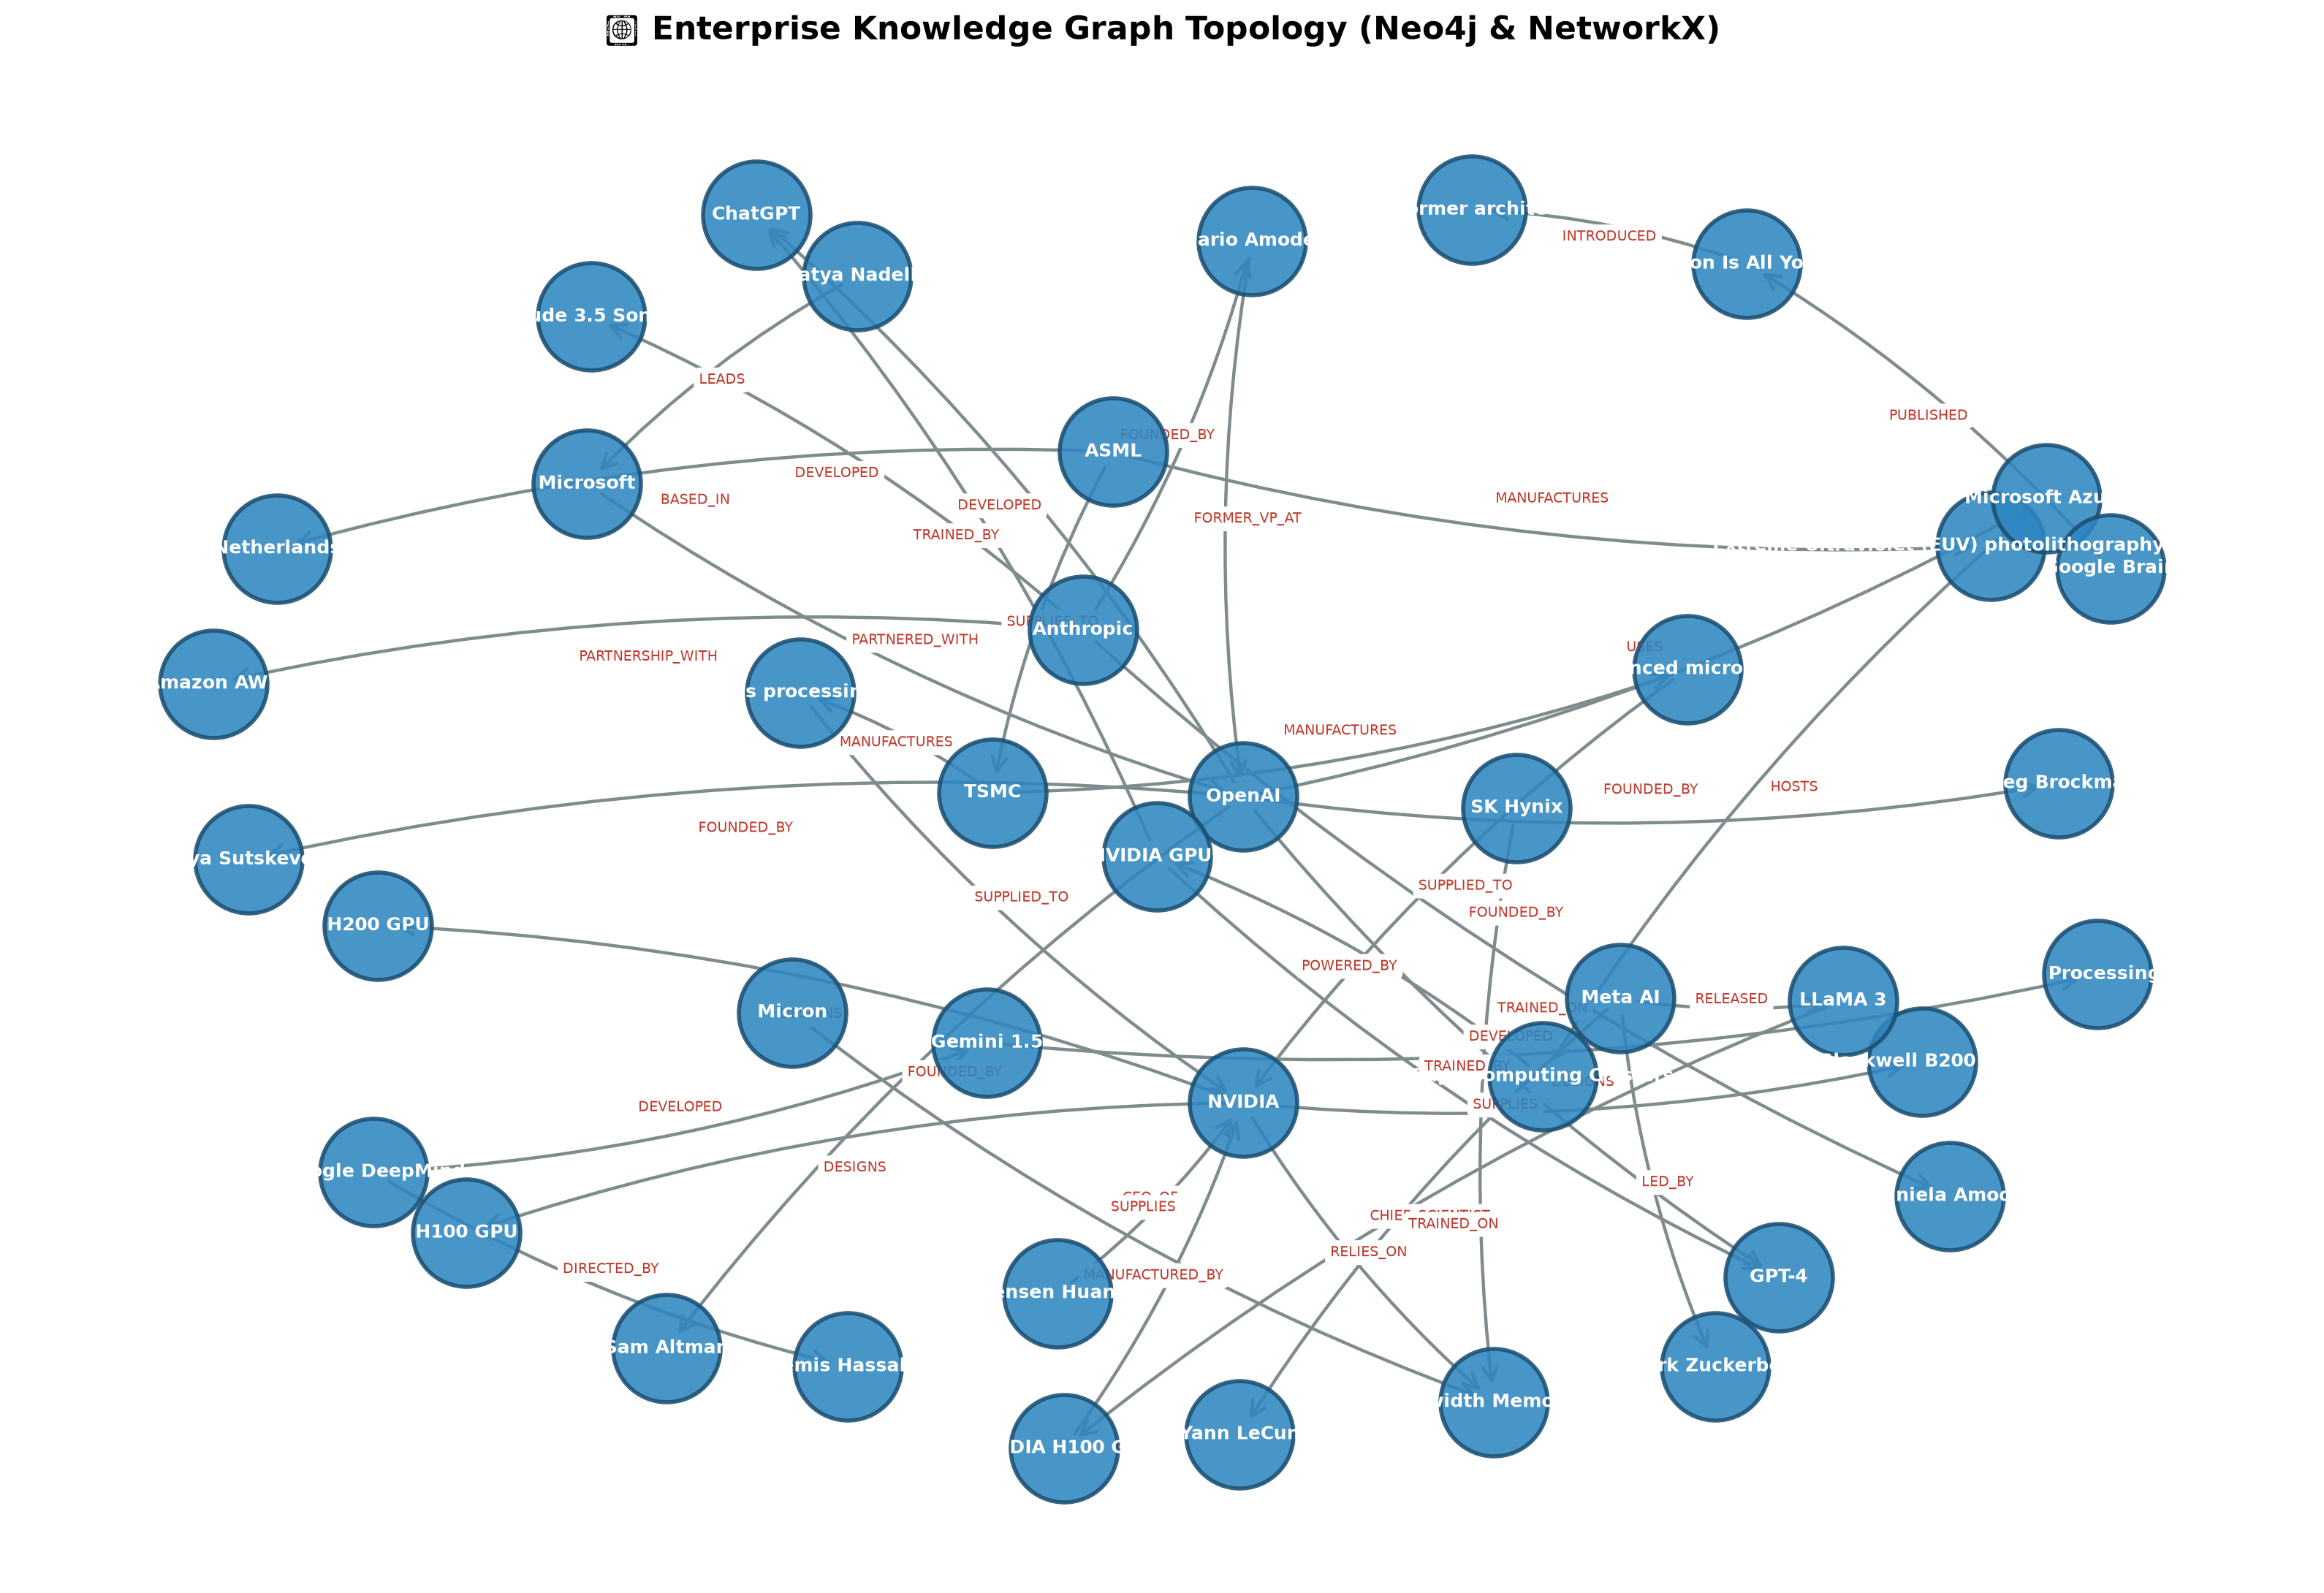

🎉 Notebook 1 execution complete! Knowledge Graph successfully built and verified in Neo4j Aura Cloud!


In [13]:
"""
Finally, we draw our entire knowledge graph using Matplotlib.
We position the nodes with a physics-based spring layout, color them attractively,
and label both the entities and the directed arrows connecting them.
This gives us an intuitive visual map of the entire tech ecosystem we just created!
"""
plt.figure(figsize=(16, 11), dpi=200)
pos = nx.spring_layout(G, k=0.9, seed=42)

# Draw nodes
nx.draw_networkx_nodes(
    G, pos,
    node_size=2800,
    node_color="#2E86C1",
    alpha=0.88,
    edgecolors="#1B4F72",
    linewidths=2.0
)

# Draw edges with arrows
nx.draw_networkx_edges(
    G, pos,
    arrowstyle="->",
    arrowsize=18,
    edge_color="#7F8C8D",
    width=1.6,
    connectionstyle="arc3,rad=0.08"
)

# Draw entity labels
nx.draw_networkx_labels(
    G, pos,
    font_size=9,
    font_weight="bold",
    font_color="#FFFFFF",
    font_family="sans-serif"
)

# Draw relationship edge labels for prominent connections
edge_labels = {(u, v): d.get("relationship", "") for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(
    G, pos,
    edge_labels=edge_labels,
    font_size=7,
    font_color="#C0392B",
    rotate=False
)

plt.title("🌐 Enterprise Knowledge Graph Topology (Neo4j & NetworkX)", fontsize=16, fontweight="bold", pad=20)
plt.axis("off")
plt.tight_layout()
plt.show()

print("🎉 Notebook 1 execution complete! Knowledge Graph successfully built and verified in Neo4j Aura Cloud!")
